In [23]:
# Route visualization notebook for GPS ping exports from this project
# If needed, install dependencies once:
# %pip install pandas matplotlib ipython contextily pyproj

from pathlib import Path
import json
import math

import pandas as pd
from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

## 1) Choose a GPS export from recordedRuns
This cell lists JSON files in `recordedRuns/` and asks you to pick one by number.

In [24]:
data_dir = Path("recordedRuns")
json_files = sorted(
    data_dir.glob("*.json"),
    key=lambda p: p.stat().st_mtime,
    reverse=True,
)

if not json_files:
    raise FileNotFoundError(
        "No .json files found in recordedRuns/. "
        "Export or copy a run there, then rerun this cell."
    )

print("Available route files:")
for i, path in enumerate(json_files, start=1):
    print(f"{i}. {path.name}")

choice_raw = input("Choose a file number (press Enter for 1): ").strip()
choice = 1 if choice_raw == "" else int(choice_raw)

if choice < 1 or choice > len(json_files):
    raise ValueError(f"Pick a number between 1 and {len(json_files)}")

data_file = json_files[choice - 1]
print(f"Using file: {data_file}")

with data_file.open("r", encoding="utf-8") as f:
    payload = json.load(f)

pings = payload.get("pings", [])
if not pings:
    raise ValueError("The JSON file has no pings to visualize.")

df = pd.DataFrame(pings)
print(f"Loaded {len(df)} pings")
display(df.head())

Available route files:
1. car-drive-test-template.json
Using file: recordedRuns\car-drive-test-template.json
Loaded 8 pings


,timestampMs,timestampIso,latitude,longitude,accuracy,altitude,altitudeAccuracy,heading,speed
0,1783346400000,2026-07-06T14:00:00.000Z,35.149691,-78.988823,6.3,112.4,10.5,92,0.0
1,1783346410000,2026-07-06T14:00:10.000Z,35.148869,-78.988550,5.8,112.3,10.2,94,3.1
2,1783346420000,2026-07-06T14:00:20.000Z,35.148772,-78.988277,5.2,112.1,9.9,96,6.5
3,1783346430000,2026-07-06T14:00:30.000Z,35.149588,-78.984412,5.0,111.9,9.7,97,9.2
4,1783346440000,2026-07-06T14:00:40.000Z,35.149861,-78.984377,4.9,111.8,9.4,99,12.8


In [25]:
track_dir = Path("tracks")
track_files = sorted(
    track_dir.glob("*.json"),
    key=lambda p: p.stat().st_mtime,
    reverse=True,
)

if not track_files:
    raise FileNotFoundError(
        "No .json files found in tracks/. Create or copy a track there, then rerun this cell."
    )

print("Available track files:")
for i, path in enumerate(track_files, start=1):
    print(f"{i}. {path.name}")

track_choice_raw = input("Choose a track number (press Enter for 1): ").strip()
track_choice = 1 if track_choice_raw == "" else int(track_choice_raw)

if track_choice < 1 or track_choice > len(track_files):
    raise ValueError(f"Pick a number between 1 and {len(track_files)}")

track_path = track_files[track_choice - 1]
print(f"Using track: {track_path}")

with track_path.open("r", encoding="utf-8") as f:
    track = json.load(f)

track_name = track.get("name", track_path.stem)
track_description = track.get("description", "")
print(f"Track name: {track_name}")
if track_description:
    print(f"Track description: {track_description}")

if not track.get("coordinates"):
    raise ValueError("The selected track file has no gate coordinates.")


Available track files:
1. starz-circuit.json
2. testTrack.json
Using track: tracks\starz-circuit.json
Track name: Starz Circuit
Track description: A small time trial around the starz gas station area


## 2) Clean, sort, and compute route distance
This cell parses timestamps, removes invalid rows, and calculates segment + cumulative distance in meters.

## 3) Detect gate crossings on the test track
This cell compares each racer segment against each gate pillar pair in `tracks/testTrack.json` and interpolates exact crossing times.

In [26]:
required = ["latitude", "longitude", "timestampIso"]
missing = [c for c in required if c not in df.columns]
if missing:
    raise KeyError(f"Missing required columns in export: {missing}")

route_df = df.copy()
route_df["timestamp"] = pd.to_datetime(route_df["timestampIso"], errors="coerce", utc=True)
route_df = route_df.dropna(subset=["latitude", "longitude", "timestamp"])
route_df = route_df.sort_values("timestamp").reset_index(drop=True)

if len(route_df) < 2:
    raise ValueError("Need at least 2 valid points to check gate crossings.")


def segment_intersection(p1, p2, q1, q2, eps=1e-12):
    """Return intersection point and parametric positions if two segments intersect."""
    x1, y1 = p1
    x2, y2 = p2
    x3, y3 = q1
    x4, y4 = q2

    den = (x1 - x2) * (y3 - y4) - (y1 - y2) * (x3 - x4)
    if abs(den) < eps:
        return None

    t = ((x1 - x3) * (y3 - y4) - (y1 - y3) * (x3 - x4)) / den
    u = ((x1 - x3) * (y1 - y2) - (y1 - y3) * (x1 - x2)) / den

    if t < -eps or t > 1 + eps or u < -eps or u > 1 + eps:
        return None

    ix = x1 + t * (x2 - x1)
    iy = y1 + t * (y2 - y1)
    return {
        "point": (ix, iy),
        "t": t,
        "u": u,
    }


def interpolate_time(start_ts, end_ts, t):
    return start_ts + (end_ts - start_ts) * t


try:
    track
except NameError as exc:
    raise NameError("Run the track selection cell before detecting gate crossings.") from exc

gates = []
for gate_index, gate_pair in enumerate(track.get("coordinates", []), start=1):
    if len(gate_pair) != 2:
        continue
    alpha = tuple(gate_pair[0])
    beta = tuple(gate_pair[1])
    gates.append({
        "gate_index": gate_index,
        "alpha": alpha,
        "beta": beta,
    })

if not gates:
    raise ValueError("No usable gates found in the selected track.")

crossings = []
for seg_index in range(1, len(route_df)):
    prev = route_df.iloc[seg_index - 1]
    curr = route_df.iloc[seg_index]
    racer_start = (float(prev.latitude), float(prev.longitude))
    racer_end = (float(curr.latitude), float(curr.longitude))

    for gate in gates:
        hit = segment_intersection(racer_start, racer_end, gate["alpha"], gate["beta"])
        if hit is None:
            continue

        cross_ts = interpolate_time(prev.timestamp, curr.timestamp, hit["t"])
        crossings.append({
            "gate_index": gate["gate_index"],
            "segment_index": seg_index,
            "segment_start_time": prev.timestamp,
            "segment_end_time": curr.timestamp,
            "cross_time": cross_ts,
            "cross_latitude": hit["point"][0],
            "cross_longitude": hit["point"][1],
            "segment_fraction": hit["t"],
        })

crossings_df = pd.DataFrame(crossings).sort_values(["cross_time", "gate_index"]).reset_index(drop=True)

if crossings_df.empty:
    print("No gate crossings detected.")
else:
    print(f"Detected {len(crossings_df)} gate crossing(s).")
    display(crossings_df)

# Summarize first start and final finish times if gates were crossed.
if crossings_df.empty:
    race_start_time = None
    race_finish_time = None
else:
    race_start_time = crossings_df.iloc[0]["cross_time"]
    race_finish_time = crossings_df.iloc[-1]["cross_time"]
    print(f"First crossing: {race_start_time}")
    print(f"Last crossing: {race_finish_time}")

# Convenience: group crossings by segment so one racer segment can hit several gates.
if not crossings_df.empty:
    grouped = crossings_df.groupby("segment_index", sort=True)["gate_index"].apply(list)
    print("Crossings per racer segment:")
    display(grouped.to_frame(name="gate_indices"))

KeyError: 'cross_time'

In [ ]:
required = ["latitude", "longitude", "timestampIso"]
missing = [c for c in required if c not in df.columns]
if missing:
    raise KeyError(f"Missing required columns in export: {missing}")

route_df = df.copy()
route_df["timestamp"] = pd.to_datetime(route_df["timestampIso"], errors="coerce", utc=True)
route_df = route_df.dropna(subset=["latitude", "longitude", "timestamp"])
route_df = route_df.sort_values("timestamp").reset_index(drop=True)

if len(route_df) < 2:
    raise ValueError("Need at least 2 valid points to draw a route.")


def haversine_m(lat1, lon1, lat2, lon2):
    r = 6_371_000.0  # Earth radius in meters
    phi1 = math.radians(lat1)
    phi2 = math.radians(lat2)
    dphi = math.radians(lat2 - lat1)
    dlambda = math.radians(lon2 - lon1)

    a = (
        math.sin(dphi / 2) ** 2
        + math.cos(phi1) * math.cos(phi2) * math.sin(dlambda / 2) ** 2
    )
    return 2 * r * math.atan2(math.sqrt(a), math.sqrt(1 - a))

segment_m = [0.0]
for i in range(1, len(route_df)):
    prev = route_df.iloc[i - 1]
    curr = route_df.iloc[i]
    d = haversine_m(prev.latitude, prev.longitude, curr.latitude, curr.longitude)
    segment_m.append(d)

route_df["segment_m"] = segment_m
route_df["cumulative_km"] = route_df["segment_m"].cumsum() / 1000

trip_duration = route_df["timestamp"].iloc[-1] - route_df["timestamp"].iloc[0]
total_distance_km = route_df["cumulative_km"].iloc[-1]

print(f"Points used: {len(route_df)}")
print(f"Total route distance: {total_distance_km:.3f} km")
print(f"Trip duration: {trip_duration}")
display(route_df[["timestamp", "latitude", "longitude", "segment_m", "cumulative_km"]].head())

Points used: 8
Total route distance: 1.085 km
Trip duration: 0 days 00:01:10


,timestamp,latitude,longitude,segment_m,cumulative_km
0,2026-07-06 14:00:00+00:00,35.149691,-78.988823,0.000000,0.000000
1,2026-07-06 14:00:10+00:00,35.148869,-78.988550,94.735804,0.094736
2,2026-07-06 14:00:20+00:00,35.148772,-78.988277,27.078489,0.121814
3,2026-07-06 14:00:30+00:00,35.149588,-78.984412,362.919716,0.484734
4,2026-07-06 14:00:40+00:00,35.149861,-78.984377,30.436448,0.515170


## 3) Render the route on an interactive map
The map shows the driver's route in blue and the gates in order, colored green for first, red for last, and yellow for the rest.

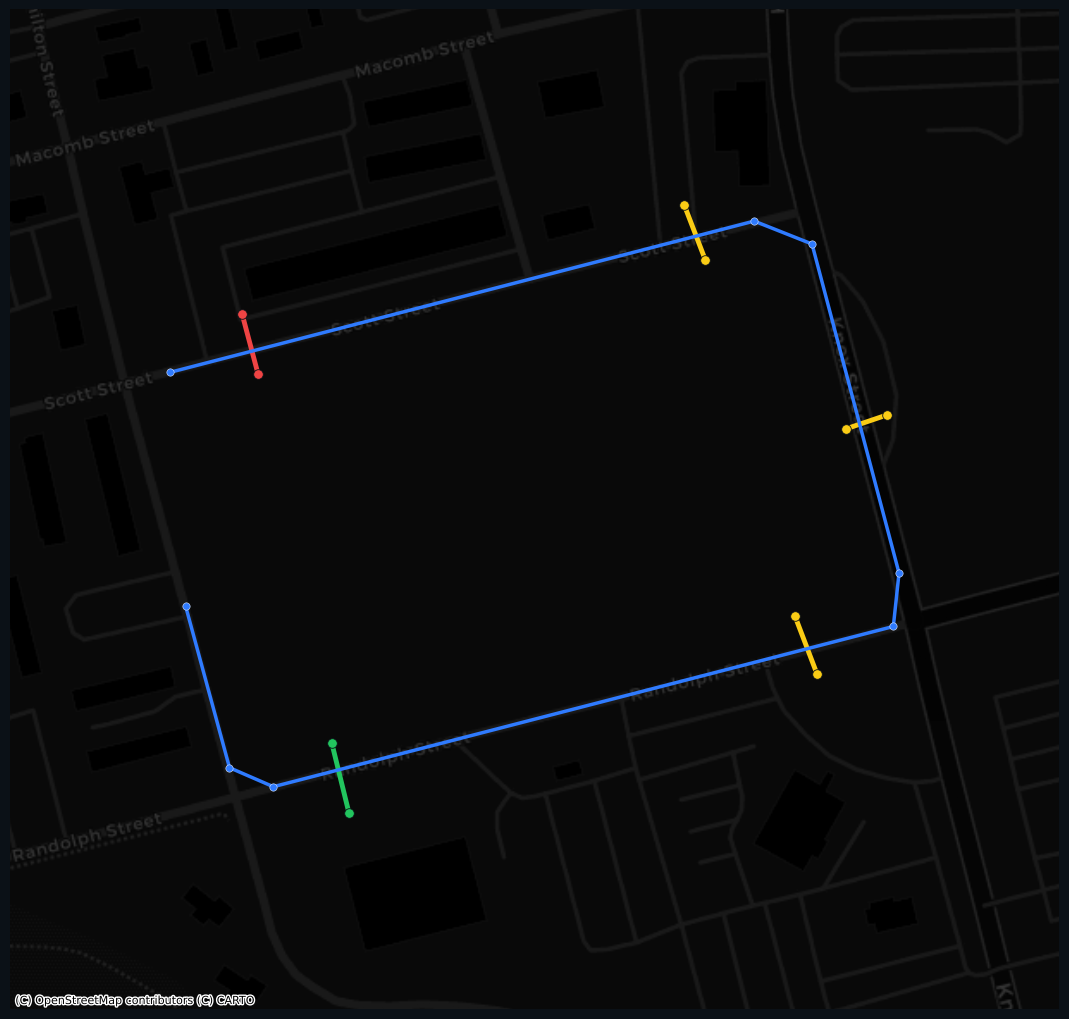

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

try:
    import contextily as ctx
    from pyproj import Transformer
except ImportError:
    ctx = None
    Transformer = None

try:
    track
except NameError as exc:
    raise NameError("Run the track selection cell before rendering the map.") from exc

gates = []
for gate_index, gate_pair in enumerate(track.get("coordinates", []), start=1):
    if len(gate_pair) != 2:
        continue
    gates.append({
        "gate_index": gate_index,
        "alpha": tuple(gate_pair[0]),
        "beta": tuple(gate_pair[1]),
    })

coords = route_df[["longitude", "latitude"]].to_numpy()
route_lons = route_df["longitude"].to_numpy()
route_lats = route_df["latitude"].to_numpy()
all_lons = [*route_lons.tolist()]
all_lats = [*route_lats.tolist()]
for gate in gates:
    all_lats.extend([gate["alpha"][0], gate["beta"][0]])
    all_lons.extend([gate["alpha"][1], gate["beta"][1]])

min_lon, max_lon = min(all_lons), max(all_lons)
min_lat, max_lat = min(all_lats), max(all_lats)
lon_pad = max((max_lon - min_lon) * 0.12, 0.001)
lat_pad = max((max_lat - min_lat) * 0.12, 0.001)

route_x = route_lons
route_y = route_lats
gate_coords = [((gate["alpha"][1], gate["alpha"][0]), (gate["beta"][1], gate["beta"][0])) for gate in gates]

fig, ax = plt.subplots(figsize=(12, 10), facecolor="#0b1117")
ax.set_facecolor("#0b1117")
fig.subplots_adjust(left=0, right=1, bottom=0, top=1)
ax.set_xlim(min_lon - lon_pad, max_lon + lon_pad)
ax.set_ylim(min_lat - lat_pad, max_lat + lat_pad)
ax.set_aspect("equal", adjustable="box")

basemap_added = False
if ctx is not None and Transformer is not None:
    try:
        transformer = Transformer.from_crs(4326, 3857, always_xy=True)
        x_min, y_min = transformer.transform(min_lon - lon_pad, min_lat - lat_pad)
        x_max, y_max = transformer.transform(max_lon + lon_pad, max_lat + lat_pad)
        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)
        route_x, route_y = transformer.transform(route_lons, route_lats)
        gate_coords = []
        for gate in gates:
            alpha_x, alpha_y = transformer.transform(gate["alpha"][1], gate["alpha"][0])
            beta_x, beta_y = transformer.transform(gate["beta"][1], gate["beta"][0])
            gate_coords.append(((alpha_x, alpha_y), (beta_x, beta_y)))
        carto_db = getattr(ctx.providers, "CartoDB", None)
        basemap_source = getattr(carto_db, "DarkMatter", None) if carto_db is not None else None
        if basemap_source is not None:
            ctx.add_basemap(ax, source=basemap_source)
            basemap_added = True
    except Exception:
        basemap_added = False

if not basemap_added:
    ax.add_patch(Rectangle((min_lon - lon_pad, min_lat - lat_pad), (max_lon - min_lon) + 2 * lon_pad, (max_lat - min_lat) + 2 * lat_pad, facecolor="#0b1117", edgecolor="#273744", linewidth=1, zorder=0))
    ax.grid(True, color="#1a2833", linewidth=0.8, alpha=0.8)

# Driver route: blue line with point markers.
ax.plot(route_x, route_y, color="#2f7bff", linewidth=2.5, zorder=3)
ax.scatter(route_x, route_y, s=28, color="#2f7bff", edgecolors="#dbe8ff", linewidths=0.4, zorder=4)

# Gates: first green, last red, middle yellow.
for index, (alpha_point, beta_point) in enumerate(gate_coords, start=1):
    if index == 1:
        gate_color = "#22c55e"
    elif index == len(gate_coords):
        gate_color = "#ef4444"
    else:
        gate_color = "#facc15"
    ax.plot([alpha_point[0], beta_point[0]], [alpha_point[1], beta_point[1]], color=gate_color, linewidth=3.5, zorder=2)
    ax.scatter([alpha_point[0], beta_point[0]], [alpha_point[1], beta_point[1]], s=48, color=gate_color, edgecolors="#0b1117", linewidths=0.6, zorder=5)

ax.set_axis_off()
ax.set_title("")
plt.show()

## 4) Run summary
This cell shows the selected run in a cleaner, easier-to-scan format.

In [ ]:
summary_rows = [
    ["Selected file", data_file.name],
    ["Ping count", len(df)],
    ["Valid route points", len(route_df)],
    ["Run completion time", str(race_finish_time - race_start_time) if race_start_time is not None and race_finish_time is not None else "n/a"],
    ["Total distance (km)", f"{total_distance_km:.3f}"],
    ["Gate crossings", 0 if crossings_df.empty else len(crossings_df)],
    ["Start time", race_start_time if race_start_time is not None else "n/a"],
    ["Finish time", race_finish_time if race_finish_time is not None else "n/a"],
]

if "speed" in route_df.columns:
    speed_series_mph = pd.to_numeric(route_df["speed"], errors="coerce") * 2.2369362920544
    speed_series_mph = speed_series_mph.dropna()
else:
    speed_series_mph = pd.Series(dtype=float)
moving_speed_mph = speed_series_mph[speed_series_mph > 0]

speed_summary_rows = [
    ["Top speed (mph)", f"{moving_speed_mph.max():.2f}" if not moving_speed_mph.empty else "n/a"],
    ["Average speed (mph)", f"{moving_speed_mph.mean():.2f}" if not moving_speed_mph.empty else "n/a"],
    ["Slowest moving speed (mph)", f"{moving_speed_mph.min():.2f}" if not moving_speed_mph.empty else "n/a"],
]

summary_df = pd.DataFrame(summary_rows, columns=["Metric", "Value"])
display(summary_df.style.hide(axis="index").set_properties(subset=["Metric", "Value"], **{
    "background-color": "#101a22",
    "color": "#e7f0f5",
    "border-color": "#273744",
}))

speed_summary_df = pd.DataFrame(speed_summary_rows, columns=["Metric", "Value"])
display(speed_summary_df.style.hide(axis="index").set_properties(subset=["Metric", "Value"], **{
    "background-color": "#101a22",
    "color": "#e7f0f5",
    "border-color": "#273744",
}))

pretty_route = route_df[["timestamp", "latitude", "longitude", "segment_m", "cumulative_km"]].copy()
pretty_route["segment_m"] = pretty_route["segment_m"].round(2)
pretty_route["cumulative_km"] = pretty_route["cumulative_km"].round(3)
def format_timestamp(value: object) -> str:
    if isinstance(value, pd.Timestamp):
        return value.strftime("%Y-%m-%d %H:%M:%S%z")
    return str(value)

pretty_route_display = pretty_route.style.hide(axis="index").format({
    "timestamp": format_timestamp,
    "latitude": "{:.6f}",
    "longitude": "{:.6f}",
})

display(pretty_route_display)

if not crossings_df.empty:
    pretty_crossings = crossings_df[[
        "gate_index",
        "segment_index",
        "cross_time",
        "cross_latitude",
        "cross_longitude",
        "segment_fraction",
    ]].copy()
    pretty_crossings["segment_fraction"] = pretty_crossings["segment_fraction"].round(4)
    def format_cross_time(value: object) -> str:
        if isinstance(value, pd.Timestamp):
            return value.strftime("%Y-%m-%d %H:%M:%S.%f%z")
        return str(value)

    pretty_crossings_display = pretty_crossings.style.hide(axis="index").format({
        "cross_time": format_cross_time,
        "cross_latitude": "{:.6f}",
        "cross_longitude": "{:.6f}",
    })
    display(pretty_crossings_display)
else:
    print("No gate crossings detected for this run.")

Metric,Value
Selected file,car-drive-test-template.json
Ping count,8
Valid route points,8
Run completion time,0 days 00:00:47.553835
Total distance (km),1.085
Gate crossings,5
Start time,2026-07-06 14:00:21.049329+00:00
Finish time,2026-07-06 14:01:08.603164+00:00


Metric,Value
Top speed (mph),38.03
Average speed (mph),25.44
Slowest moving speed (mph),6.93


timestamp,latitude,longitude,segment_m,cumulative_km
2026-07-06 14:00:00+0000,35.149691,-78.988823,0.000000,0.000000
2026-07-06 14:00:10+0000,35.148869,-78.988550,94.740000,0.095000
2026-07-06 14:00:20+0000,35.148772,-78.988277,27.080000,0.122000
2026-07-06 14:00:30+0000,35.149588,-78.984412,362.920000,0.485000
2026-07-06 14:00:40+0000,35.149861,-78.984377,30.440000,0.515000
2026-07-06 14:00:50+0000,35.151538,-78.984919,192.920000,0.708000
2026-07-06 14:01:00+0000,35.151655,-78.985279,35.240000,0.743000
2026-07-06 14:01:10+0000,35.150884,-78.988918,341.750000,1.085000


gate_index,segment_index,cross_time,cross_latitude,cross_longitude,segment_fraction
1,3,2026-07-06 14:00:21.049329+0000,35.148857,-78.987871,0.104900
2,3,2026-07-06 14:00:28.613848+0000,35.149475,-78.984948,0.861400
3,5,2026-07-06 14:00:44.523634+0000,35.150619,-78.984622,0.452400
4,7,2026-07-06 14:01:00.993965+0000,35.151578,-78.985641,0.099400
5,7,2026-07-06 14:01:08.603164+0000,35.150992,-78.988410,0.860300
